# Sequencing-depth scaling law

AUROC vs depth for five methods, one panel per disease (Lupus | HIV).

Error bars are mean +/- standard error (the values reported in the benchmarking spreadsheet).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Config

In [2]:
METHODS = [
    "Emerson 2017",
    "V/J-gkmer (LogReg)",
    "DeepRC",
    "GIANA",
    "Mal-ID",
]

DISEASES = ["Lupus", "HIV"]

DEPTHS = [1000, 5000, 10000, 25000, 50000, 75000]

METHOD_COLORS = {
    "Emerson 2017":        "#332288",
    "Ostmeyer 2019":       "#DDCC77",
    "V/J-gkmer (LogReg)":  "#CC6677",
    "V/J-gkmer (XGBoost)": "#AA4499",
    "ABMIL":               "#CB9947",
    "GIANA":               "#88CCEE",
    "DeepRC":              "#117733",
    "DeepTCR":             "#44AA99",
    "Mal-ID":              "#882255",
}

NA = np.nan

## Results table

AUROC mean and standard error per (disease, method, depth). Values from the scaling-law spreadsheet. GIANA and Mal-ID rows are placeholders until those experiments are run. Disease assignment (Lupus vs. HIV) for the table below to be confirmed.

In [3]:
RESULTS = {
    "Lupus": {
        "Emerson 2017": {
            "mean": [0.5001, 0.6001, 0.6419, 0.7073, 0.7516, 0.7462],
            "se":   [0.0035, 0.0165, 0.0108, 0.0153, 0.0206, 0.0215],
        },
        "V/J-gkmer (LogReg)": {
            "mean": [0.8965, 0.9223, 0.9247, 0.9309, 0.9371, 0.9251],
            "se":   [0.0100, 0.0034, 0.0033, 0.0023, 0.0066, 0.0059],
        },
        "DeepRC": {
            "mean": [0.6272, 0.7474, 0.7841, 0.8143, 0.7761, 0.8181],
            "se":   [0.0354, 0.0224, 0.0330, 0.0467, 0.0075, 0.0324],
        },
        "GIANA": {
            "mean": [NA, NA, NA, NA, NA, NA],
            "se":   [NA, NA, NA, NA, NA, NA],
        },
        "Mal-ID": {
            "mean": [NA, NA, NA, NA, NA, NA],
            "se":   [NA, NA, NA, NA, NA, NA],
        },
    },
    "HIV": {
        "Emerson 2017": {
            "mean": [0.6534, 0.7302, 0.7383, 0.7535, 0.8080, 0.8780],
            "se":   [0.0344, 0.0235, 0.0075, 0.0142, 0.0174, 0.0082],
        },
        "V/J-gkmer (LogReg)": {
            "mean": [0.8837, 0.8973, 0.8795, 0.9036, 0.8954, 0.9099],
            "se":   [0.0100, 0.0132, 0.0071, 0.0071, 0.0053, 0.0041],
        },
        "DeepRC": {
            "mean": [0.6808, 0.7531, 0.7872, 0.7502, 0.8202, 0.8051],
            "se":   [0.0214, 0.0182, 0.0196, 0.0179, 0.0154, 0.0162],
        },
        "GIANA": {
            "mean": [NA, NA, NA, NA, NA, NA],
            "se":   [NA, NA, NA, NA, NA, NA],
        },
        "Mal-ID": {
            "mean": [NA, NA, NA, NA, NA, NA],
            "se":   [NA, NA, NA, NA, NA, NA],
        },
    },
}

## Plot helpers

In [4]:
def plot_scaling_panel(ax, disease, show_xlabel=True):
    for method in METHODS:
        mean = np.array(RESULTS[disease][method]["mean"], dtype=float)
        se = np.array(RESULTS[disease][method]["se"], dtype=float)
        if np.all(np.isnan(mean)):
            continue
        ax.errorbar(
            DEPTHS, mean, yerr=se,
            label=method, color=METHOD_COLORS[method],
            marker="o", markersize=4, linewidth=1.4, capsize=2.5,
        )
    ax.set_xscale("log")
    ax.set_xticks(DEPTHS)
    ax.set_xticklabels(
        [f"{d // 1000}k" if d >= 1000 else str(d) for d in DEPTHS],
        fontsize=8.5, rotation=45, ha="right", rotation_mode="anchor",
    )
    ax.set_xlim(DEPTHS[0] * 0.92, DEPTHS[-1] * 1.08)
    ax.minorticks_off()
    if show_xlabel:
        ax.set_xlabel(r"Sequences per repertoire (log$_{10}$ scale)", fontsize=11)
    ax.set_ylabel("AUROC", fontsize=11)
    ax.tick_params(axis="y", labelsize=10)
    ax.set_title(disease, fontsize=11, fontweight="bold", pad=4)
    ax.grid(True, which="major", linestyle=":", alpha=0.5)


def make_figure(out_path=None):
    fig, axes = plt.subplots(
        2, 1, figsize=(4.8, 5.8), sharex=True, sharey=True,
    )
    fig.subplots_adjust(left=0.16, right=0.97, top=0.95, bottom=0.18, hspace=0.25)
    for i, (ax, disease) in enumerate(zip(axes, DISEASES)):
        plot_scaling_panel(ax, disease, show_xlabel=(i == len(DISEASES) - 1))
    handles, labels = axes[0].get_legend_handles_labels()
    if not handles:
        handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.03),
        ncol=2, frameon=False, fontsize=11,
    )
    if out_path:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    return fig

## Render

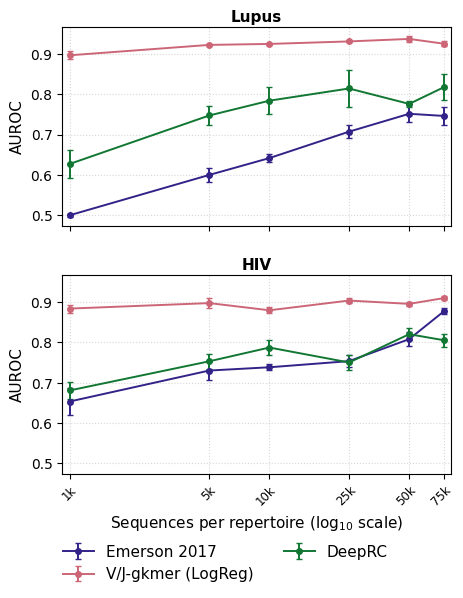

In [5]:
fig = make_figure(out_path="scaling_law.pdf")
plt.show()